# Бизнес-анализ данных Olist

Цель проекта — проанализировать продажи, товарные категории, клиентскую базу и доставку Olist, чтобы определить ключевые источники выручки, оценить ценность разных групп клиентов и понять, как сроки доставки связаны с клиентскими оценками.

В ноутбуке рассматриваются пять вопросов:

1. Как менялись выручка, количество заказов и средний чек Olist по месяцам?
2. Какие категории товаров вносят наибольший вклад в выручку и количество заказов?
3. Какую роль в продажах играют новые и повторные клиенты?
4. Какие клиентские сегменты наиболее ценны для бизнеса?
5. Как сроки и задержки доставки связаны с оценками клиентов?


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

valid_sales_orders = pd.read_csv(DATA_DIR / "valid_sales_orders.csv", low_memory=False)
order_items_enriched = pd.read_csv(DATA_DIR / "order_items_enriched.csv", low_memory=False)
customers_segmented = pd.read_csv(DATA_DIR / "customers_segmented.csv", low_memory=False)
delivery_reviews_base = pd.read_csv(DATA_DIR / "delivery_reviews_base.csv", low_memory=False)

valid_sales_orders["order_purchase_timestamp"] = pd.to_datetime(
    valid_sales_orders["order_purchase_timestamp"], errors="coerce"
)
valid_sales_orders["order_month"] = (
    valid_sales_orders["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
)

In [3]:
ANALYSIS_START = pd.Timestamp("2017-01-01")
ANALYSIS_END = pd.Timestamp("2018-08-01")

sales_orders = valid_sales_orders.query(
    "@ANALYSIS_START <= order_purchase_timestamp < @ANALYSIS_END"
).copy()

order_items = order_items_enriched[
    order_items_enriched["order_id"].isin(sales_orders["order_id"])
].copy()

delivery_reviews = delivery_reviews_base[
    delivery_reviews_base["order_id"].isin(sales_orders["order_id"])
].copy()

pd.Series(
    {
        name: len(df)
        for name, df in {
            "sales_orders": sales_orders,
            "order_items": order_items,
            "customers_segmented": customers_segmented,
            "delivery_reviews": delivery_reviews,
        }.items()
    },
    name="Строки",
)

sales_orders            89860
order_items            102738
customers_segmented     93357
delivery_reviews        89230
Name: Строки, dtype: int64

In [4]:
pd.Series(
    {
        "Период анализа": f"{sales_orders['order_month'].min():%Y-%m} — {sales_orders['order_month'].max():%Y-%m}",
        "Количество заказов": sales_orders["order_id"].nunique(),
        "Количество клиентов": sales_orders["customer_unique_id"].nunique(),
        "Выручка": sales_orders["payment_value"].sum(),
        "Средний чек": sales_orders["payment_value"].sum() / sales_orders["order_id"].nunique(),
    },
    name="Значение",
)

Период анализа         2017-01 — 2018-07
Количество заказов                 89860
Количество клиентов                86960
Выручка                    14,390,461.16
Средний чек                       160.14
Name: Значение, dtype: object

## 1. Динамика выручки, заказов и среднего чека

Анализ показывает, как менялись продажи Olist по месяцам и за счёт чего двигалась выручка: количества заказов или среднего чека.


In [5]:
monthly_sales = sales_orders.groupby("order_month", as_index=False).agg(
    orders=("order_id", "nunique"), revenue=("payment_value", "sum")
)
monthly_sales["avg_order_value"] = monthly_sales["revenue"] / monthly_sales["orders"]

monthly_sales.rename(
    columns={
        "order_month": "Месяц",
        "orders": "Заказы",
        "revenue": "Выручка",
        "avg_order_value": "Средний чек",
    }
)

,Месяц,Заказы,Выручка,Средний чек
0,2017-01-01,750,"127,545.67",170.06
1,2017-02-01,1653,"271,298.65",164.13
2,2017-03-01,2546,"414,369.39",162.75
3,2017-04-01,2303,"390,952.18",169.76
4,2017-05-01,3546,"567,066.73",159.92
5,2017-06-01,3135,"490,225.60",156.37
6,2017-07-01,3872,"566,403.93",146.28
7,2017-08-01,4193,"646,000.61",154.07
8,2017-09-01,4150,"701,169.99",168.96
9,2017-10-01,4478,"751,140.27",167.74


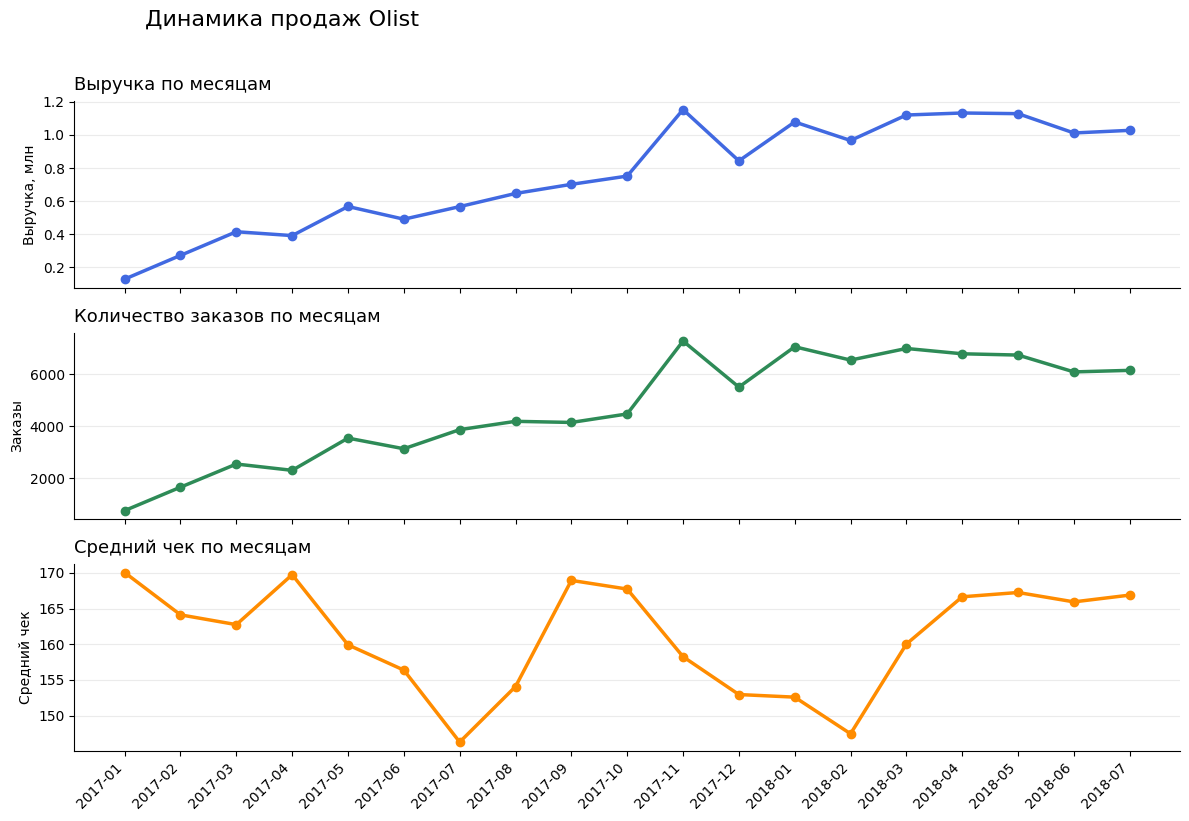

In [6]:
plot_data = monthly_sales.reset_index(drop=True)
x = np.arange(len(plot_data))
months = plot_data["order_month"].dt.strftime("%Y-%m")

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(x, plot_data["revenue"] / 1_000_000, marker="o", linewidth=2.5, color="royalblue")
axes[1].plot(x, plot_data["orders"], marker="o", linewidth=2.5, color="seagreen")
axes[2].plot(x, plot_data["avg_order_value"], marker="o", linewidth=2.5, color="darkorange")

titles = ["Выручка по месяцам", "Количество заказов по месяцам", "Средний чек по месяцам"]
ylabels = ["Выручка, млн", "Заказы", "Средний чек"]

for ax, title, ylabel in zip(axes, titles, ylabels):
    ax.set_title(title, loc="left", fontsize=13, pad=8)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(months, rotation=45, ha="right")

fig.suptitle("Динамика продаж Olist", x=0.125, y=1.02, ha="left", fontsize=16)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sales_dynamics.png", dpi=200, bbox_inches="tight")
plt.show()

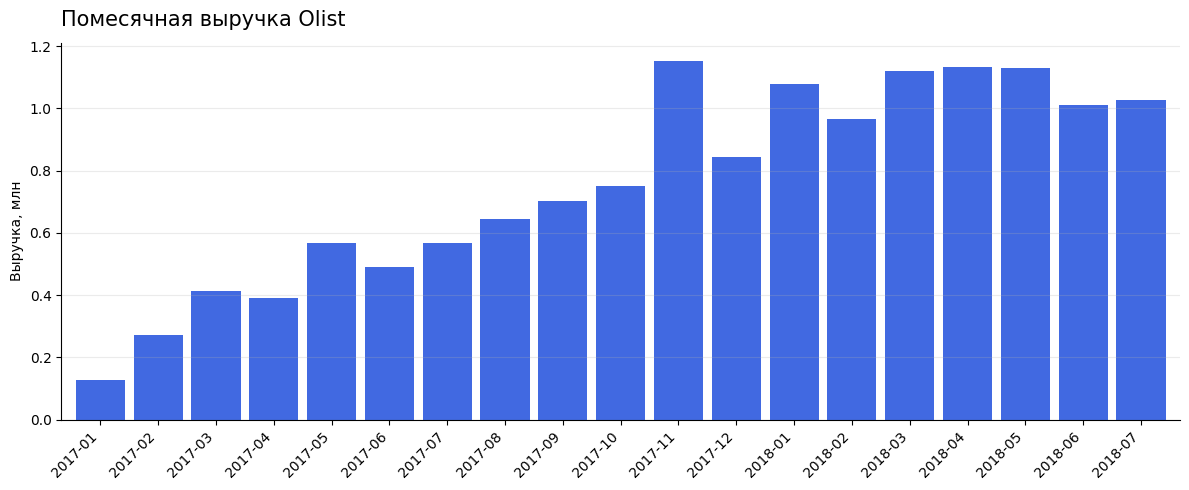

In [7]:
ax = plot_data.set_index("order_month")["revenue"].plot(
    kind="bar", figsize=(12, 5), width=0.85, color="royalblue"
)

ax.set_title("Помесячная выручка Olist", loc="left", fontsize=15, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Выручка, млн")
ax.set_xticklabels([d.strftime("%Y-%m") for d in plot_data["order_month"]], rotation=45, ha="right")
ax.yaxis.set_major_formatter(lambda value, _: f"{value / 1_000_000:.1f}")
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_revenue.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Анализ товарных категорий

Блок показывает, какие товарные категории дают наибольший вклад в выручку и количество заказов.

Для общей динамики продаж используется `payment_value`, так как он отражает сумму оплаты заказа. Для анализа товарных категорий используется `price`, потому что стоимость доставки и общая оплата заказа не всегда корректно распределяются между категориями внутри одного заказа.


In [8]:
category_sales = (
    order_items.assign(category=order_items["product_category_name_english"].fillna("unknown"))
    .groupby("category", as_index=False)
    .agg(orders=("order_id", "nunique"), revenue=("price", "sum"))
    .assign(revenue_share=lambda df: df["revenue"] / df["revenue"].sum())
    .sort_values("revenue", ascending=False)
)

category_sales.head(15).rename(
    columns={
        "category": "Категория",
        "orders": "Заказы",
        "revenue": "Выручка",
        "revenue_share": "Доля выручки",
    }
)

,Категория,Заказы,Выручка,Доля выручки
43,health_beauty,7845,"1,110,166.49",0.09
71,watches_gifts,5104,"1,093,698.85",0.09
7,bed_bath_table,8712,"962,064.68",0.08
65,sports_leisure,7081,"901,980.22",0.07
15,computers_accessories,6138,"848,002.95",0.07
39,furniture_decor,5917,"665,068.62",0.05
20,cool_stuff,3436,"593,363.11",0.05
49,housewares,5185,"555,578.26",0.05
5,auto,3457,"532,805.81",0.04
42,garden_tools,3323,"452,820.70",0.04


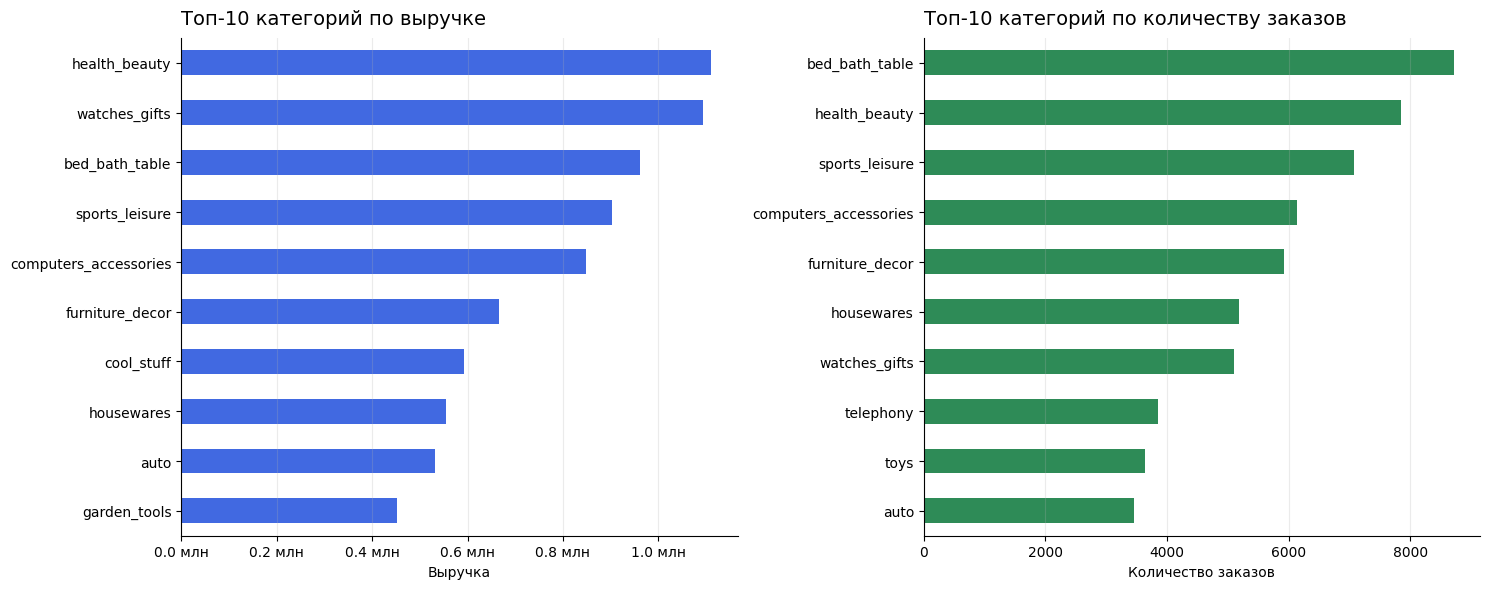

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

category_sales.head(10).sort_values("revenue").plot.barh(
    x="category", y="revenue", ax=axes[0], color="royalblue", legend=False
)

category_sales.sort_values("orders", ascending=False).head(10).sort_values("orders").plot.barh(
    x="category", y="orders", ax=axes[1], color="seagreen", legend=False
)

axes[0].set_title("Топ-10 категорий по выручке", loc="left", fontsize=14, pad=10)
axes[0].set_xlabel("Выручка")
axes[1].set_title("Топ-10 категорий по количеству заказов", loc="left", fontsize=14, pad=10)
axes[1].set_xlabel("Количество заказов")

axes[0].xaxis.set_major_formatter(lambda value, _: f"{value / 1_000_000:.1f} млн")

for ax in axes:
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_categories.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Анализ клиентов

Блок показывает, какую роль в продажах играют первые покупки клиентов и повторные заказы.


In [10]:
customer_orders = (
    valid_sales_orders.sort_values("order_purchase_timestamp")
    .assign(order_number=lambda df: df.groupby("customer_unique_id").cumcount() + 1)
    .assign(customer_type=lambda df: np.where(df["order_number"].eq(1), "Новые", "Повторные"))
    .query("@ANALYSIS_START <= order_purchase_timestamp < @ANALYSIS_END")
)

customer_role = (
    customer_orders.groupby("customer_type", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        orders=("order_id", "nunique"),
        revenue=("payment_value", "sum"),
    )
    .assign(
        orders_share=lambda df: df["orders"] / df["orders"].sum(),
        revenue_share=lambda df: df["revenue"] / df["revenue"].sum(),
    )
    .sort_values("revenue", ascending=False)
)

customer_role.rename(
    columns={
        "customer_type": "Тип клиента",
        "customers": "Клиенты",
        "orders": "Заказы",
        "revenue": "Выручка",
        "orders_share": "Доля заказов",
        "revenue_share": "Доля выручки",
    }
)

,Тип клиента,Клиенты,Заказы,Выручка,Доля заказов,Доля выручки
0,Новые,86950,86950,"13,963,967.07",0.97,0.97
1,Повторные,2618,2910,"426,494.09",0.03,0.03


## 4. Ценность клиентских сегментов

Блок сравнивает клиентские сегменты по количеству клиентов, заказам, выручке и средней ценности клиента.


In [11]:
segment_sales = (
    sales_orders.groupby("customer_segment", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        orders=("order_id", "nunique"),
        revenue=("payment_value", "sum"),
    )
    .assign(
        revenue_share=lambda df: df["revenue"] / df["revenue"].sum(),
        avg_customer_value=lambda df: df["revenue"] / df["customers"],
    )
    .sort_values("revenue", ascending=False)
)

segment_sales.rename(
    columns={
        "customer_segment": "Сегмент",
        "customers": "Клиенты",
        "orders": "Заказы",
        "revenue": "Выручка",
        "revenue_share": "Доля выручки",
        "avg_customer_value": "Средняя ценность клиента",
    }
)

,Сегмент,Клиенты,Заказы,Выручка,Доля выручки,Средняя ценность клиента
3,ценные давние разовые клиенты,10633,10633,"4,170,317.91",0.29,392.21
4,ценные недавние разовые клиенты,9485,9485,"3,697,187.45",0.26,389.79
2,разовые клиенты средней ценности,21081,21081,"2,968,781.39",0.21,140.83
1,разовые клиенты низкой текущей ценности,42997,42997,"2,728,240.68",0.19,63.45
5,ценные повторные клиенты,2432,5013,"799,349.03",0.06,328.68
0,остальные повторные клиенты,332,651,"26,584.70",0.00,80.07


## 5. Доставка и оценки клиентов

Блок показывает, как сроки и задержки доставки связаны с оценками клиентов.


In [12]:
delivery_impact = (
    delivery_reviews.groupby("delivery_status", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        avg_review=("review_score", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
        late_share=("is_delivered_late", "mean"),
    )
    .assign(late_share=lambda df: df["late_share"] * 100)
    .sort_values("avg_review", ascending=False)
)

delivery_impact.rename(
    columns={
        "delivery_status": "Статус доставки",
        "orders": "Заказы",
        "avg_review": "Средняя оценка",
        "avg_delivery_days": "Средний срок доставки",
        "avg_delay_days": "Среднее отклонение от срока",
        "late_share": "Доля задержек, %",
    }
)

,Статус доставки,Заказы,Средняя оценка,Средний срок доставки,Среднее отклонение от срока,"Доля задержек, %"
0,доставлен без задержки,82223,4.29,11.09,-13.23,0.00
1,доставлен с задержкой,7007,2.48,33.27,10.02,100.00


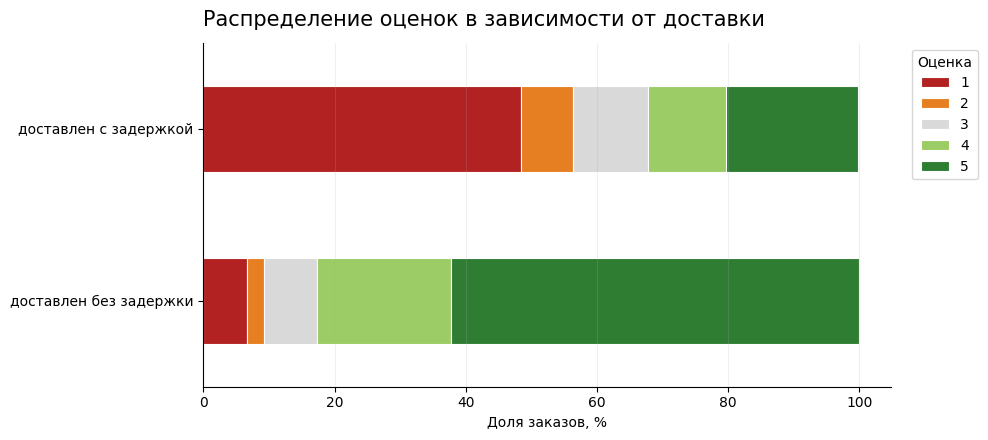

In [13]:
review_distribution = (
    pd.crosstab(
        delivery_reviews["delivery_status"], delivery_reviews["review_score"], normalize="index"
    )
    .mul(100)
    .reindex(columns=[1, 2, 3, 4, 5], fill_value=0)
)

ax = review_distribution.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 4.5),
    color=["#B22222", "#E67E22", "#D9D9D9", "#9CCC65", "#2E7D32"],
    edgecolor="white",
    linewidth=0.8,
)

ax.set_title("Распределение оценок в зависимости от доставки", loc="left", fontsize=15, pad=12)
ax.set_xlabel("Доля заказов, %")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Оценка", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "delivery_reviews.png", dpi=200, bbox_inches="tight")
plt.show()

## Краткие выводы по анализу

За период с 2017-01 по 2018-07 в валидных продажах Olist было проанализировано 89 860 заказов на сумму 14.39 млн. Средний чек составил 160.14.

Основная выручка сконцентрирована в нескольких товарных категориях: категория `health_beauty` стала лидером, а топ-5 категорий сформировали около 40% выручки.

Повторные клиенты дали около 3% выручки, поэтому продажи в рассматриваемом датасете в основном зависят от новых покупателей.

Наибольшую выручку среди клиентских сегментов дали `ценные давние разовые клиенты`, что показывает важность разовых покупателей с высокой покупательной ценностью.

Средняя оценка заказов составила 4.15, а около 8% заказов были доставлены с задержкой.

Более подробная интерпретация результатов и бизнес-рекомендации вынесены в README.
